In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [49]:
df = pd.read_csv('../Datasets/height_weight.csv')
df.head()  

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [50]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


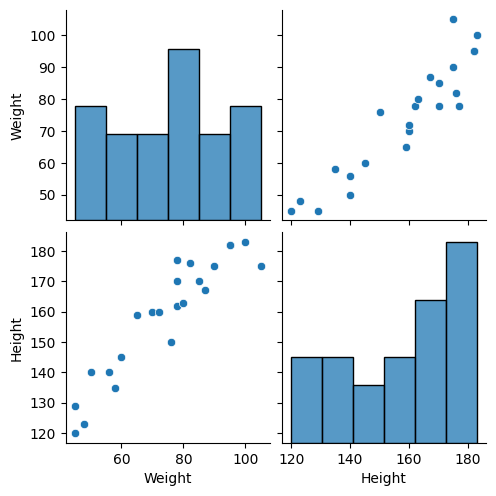

In [51]:
sns.pairplot(df)

In [52]:
## check for null values
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [53]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [54]:
## divide independent and dependent features
X = df.drop('Height', axis=1)
y = df['Height']

In [55]:
## split data into training and testing dataset
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [56]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [57]:
## Scaling independent features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [58]:
X_train_norm = scaler.fit_transform(X_train)
X_train_norm

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [59]:
X_test_norm = scaler.transform(X_test)
X_test_norm

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [60]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [61]:
reg.fit(X_train_norm, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
print(reg.coef_)
print(reg.intercept_)

[17.2982057]
156.47058823529412


In [63]:
y_preds = reg.predict(X_test_norm)

In [64]:
from sklearn.metrics import r2_score

scr = r2_score(y_preds, y_test)
print(scr)

0.7242334405003442


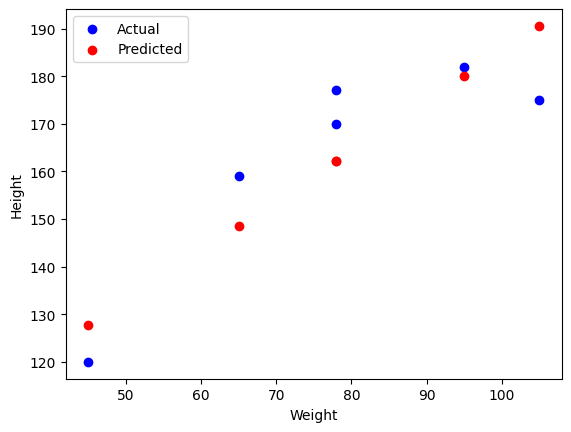

In [65]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_preds, color='red', label='Predicted')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()


In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_preds)
mse = mean_squared_error(y_test, y_preds)
rmse = root_mean_squared_error(y_test, y_preds)

In [67]:
print(mae)
print(mse)
print(rmse)

9.66512588679501
114.84069295228699
10.716374991212605


In [68]:
## OLS Linear Regression
import statsmodels.api as sm

In [77]:
model = sm.OLS(y_train, X_train_norm).fit()

In [78]:
prediction = model.predict(X_test_norm)

In [79]:
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [80]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 04 Mar 2026   Prob (F-statistic):                       0.664
Time:                        23:21:00   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------